In [1]:
%load_ext autoreload
%autoreload 2

In [128]:
from power_systems_ops.read import login, read_tables, navigate

In [ ]:
import numpy as np
import pandas as pd

In [7]:
driver = login("coned@colorado.edu", "2025NYTeam")

In [129]:
tables = read_tables(driver)

Power plant portfolio
Electricity generation and fuel consumption in the past round
Electricity production per plant
Power plant availability
Overview of power plants
Fuel characteristics
Coal
Biomass
Natural gas
Nuclear fuel
Wind availability
Solar
Electricity demand
Invest in a new power plant
Dismantle power plants
Offer a plant for sale
Plants currently offered for sale
Accept offered plant
Sold plants


In [130]:
tables.keys()

dict_keys(['dispatch', 'last_generation', 'overview', 'fuels', 'coal', 'biomass', 'naturalgas', 'nuclear', 'wind', 'solar', 'demand', 'invest', 'Dismantle power plants', 'Offer a plant for sale', 'Plants currently offered for sale', 'Accept offered plant'])

In [131]:
tables['invest']

,Plant name,Type,rel,eff,construct,permit,life_exp,down,loan,num_loan,maint,cap_range,cap_range,Buy
0,,naturalgasCCGT,96.0,59.9,3,1,30,0.146,0.056,15,0.062,500.00-900.00,,
1,,wind,96.0,NaN,1,1,25,0.443,0.171,15,0.047,100.00-700.00,,
2,,naturalgasOCGT,96.0,39.9,2,0,30,0.111,0.058,10,0.025,100.00-500.00,,
3,,solar,96.0,0.0,1,1,25,0.142,0.055,15,0.020,100.00-700.00,,
4,,powderCoal,96.0,41.8,4,1,40,0.269,0.086,20,0.120,400.00-1000.00,,
5,,nuclear,96.0,34.1,5,2,50,1.200,0.385,20,0.110,900.00-1300.00,,
6,,biomass,96.0,41.8,4,1,40,0.288,0.092,20,0.129,400.00-1000.00,,


In [132]:
inv = tables['invest']
total_cost = inv['down'] + inv['maint'] * inv['life_exp'] + inv['loan'] * inv['num_loan']
inv['lifetime_cost'] = total_cost

In [133]:
from power_systems_ops.costs import compute_fuel_costs

In [135]:
dispatch = tables['dispatch']
compute_fuel_costs(tables, dispatch['eff'], dispatch['type'], 1)

1
1
1
1
1
1
1
Name
e9        0.00
e4        0.00
e3        0.00
e1     1368.07
e2       38.44
e10      41.33
e6        0.16
e5        0.16
e8        0.16
e7        0.16
Name: type, dtype: float64


Name
e9      0.000000
e4      0.000000
e3      0.000000
e1      3.777905
e2     13.772978
e10    23.649238
e6     30.421861
e5     32.167573
e8     43.916478
e7     45.523178
dtype: float64

In [139]:
inv.index = inv['Type']
# dispatch = tables['dispatch']
inv['fuel'] = compute_fuel_costs(tables, inv['eff'], inv['Type'], 4)

4
4
4
4
4
Type
naturalgasCCGT       0.17
wind                 0.00
naturalgasOCGT       0.17
solar                0.00
powderCoal          71.88
nuclear           1402.79
biomass             22.33
Name: Type, dtype: float64


In [140]:
price = [
    20, 35, 40
]
volume = [
    # Time per period in hr
    5000, 3600, 160
]

profits = {}
# capacity factor -- 
# Want to compute the $ revenue / MW -- 
annual_profit = np.zeros_like(inv['fuel'])
for i, period in enumerate(['off', 'shoulder', 'peak']):
    profit_per_MWh = (price[i] - inv['fuel'])
    profits[f'per_MWh_{period}'] = profit_per_MWh
    annual_profit += profit_per_MWh * volume[i]

annual = 'annual (M€/(MW*year)'
profits[annual] = annual_profit / 1e6
profits = pd.DataFrame(profits)
profits.index = inv['Type']



In [141]:
comp = tables['overview']

In [142]:
inv['fuel']

Type
naturalgasCCGT    29.134074
wind               0.000000
naturalgasOCGT    43.737620
solar              0.000000
powderCoal        24.762488
nuclear            3.809031
biomass           12.407470
Name: fuel, dtype: float64

In [149]:
comp['marginal'] = comp['Type'].map(lambda typ: inv['fuel'].loc[typ])

In [150]:
comp

,Company,Type,cap,Round active,Round dismantled,status,marginal
Plant name,,,,,,,
inv-solar-1,Dominion,solar,700.0,3,,operational,0.000000
inv-wind-1,Dominion,wind,700.0,3,,operational,0.000000
inv-wind-2,Dominion,wind,300.0,3,,operational,0.000000
inv-solar-2,Dominion,solar,700.0,3,,operational,0.000000
inv-solar-3,Dominion,solar,700.0,3,,operational,0.000000
...,...,...,...,...,...,...,...
Solar R2,Duke Energy,solar,700.0,4,,under construction,0.000000
solar1,Xcel,solar,100.0,4,,under construction,0.000000
solar2,Xcel,solar,100.0,4,,under construction,0.000000


In [176]:
(comp['Type'] == 'solar').sum()

np.int64(21)

In [156]:
tables['solar']

,avail
Round,
4,14.0
3,17.0
2,42.0
1,46.0
0,41.0
-1,14.0
-2,23.0
-3,27.0
-4,37.0


In [163]:
def get_availability(tables, type_, round=None):
    if type_ not in ['solar', 'wind']:
        return 1
        
    table = tables[type_]
    if round is None:
        round = table.index.max()
        
    return table['avail'].loc[round] / 100

In [164]:
comp['availability'] = comp['Type'].map(lambda typ: get_availability(tables, typ, 4))

In [171]:
comp_sorted = comp.sort_values(by='marginal')

comp_sorted['agg'] = np.cumsum(comp_sorted['cap'] * comp_sorted['availability'])

<Axes: xlabel='Round'>

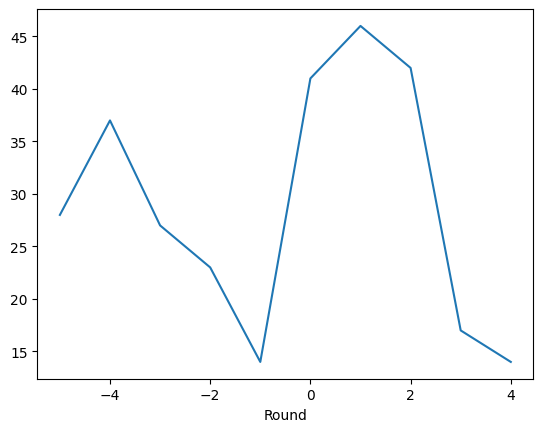

In [178]:
tables['solar']['avail'].plot()

In [172]:
comp

,Company,Type,cap,Round active,Round dismantled,status,marginal,availability
Plant name,,,,,,,,
inv-solar-1,Dominion,solar,700.0,3,,operational,0.000000,0.14
inv-wind-1,Dominion,wind,700.0,3,,operational,0.000000,0.76
inv-wind-2,Dominion,wind,300.0,3,,operational,0.000000,0.76
inv-solar-2,Dominion,solar,700.0,3,,operational,0.000000,0.14
inv-solar-3,Dominion,solar,700.0,3,,operational,0.000000,0.14
...,...,...,...,...,...,...,...,...
Solar R2,Duke Energy,solar,700.0,4,,under construction,0.000000,0.14
solar1,Xcel,solar,100.0,4,,under construction,0.000000,0.14
solar2,Xcel,solar,100.0,4,,under construction,0.000000,0.14


In [153]:
import matplotlib.pyplot as plt

<Axes: xlabel='agg', ylabel='marginal'>

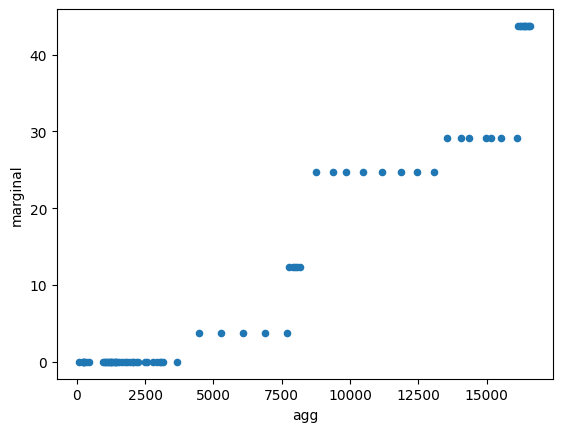

In [173]:
comp_sorted.plot.scatter(x='agg', y='marginal')

In [183]:
comp.groupby("Type").sum(True)['cap']

Type
biomass            480.0
naturalgasCCGT    3050.0
naturalgasOCGT     485.0
nuclear           4000.0
powderCoal        4900.0
solar             9100.0
wind              3165.0
Name: cap, dtype: float64

In [179]:
help(comp.groupby)

Help on method groupby in module pandas.core.frame:

groupby(by=None, axis: 'Axis | lib.NoDefault' = <no_default>, level: 'IndexLabel | None' = None, as_index: 'bool' = True, sort: 'bool' = True, group_keys: 'bool' = True, observed: 'bool | lib.NoDefault' = <no_default>, dropna: 'bool' = True) -> 'DataFrameGroupBy' method of pandas.core.frame.DataFrame instance
    Group DataFrame using a mapper or by a Series of columns.

    A groupby operation involves some combination of splitting the
    object, applying a function, and combining the results. This can be
    used to group large amounts of data and compute operations on these
    groups.

    Parameters
    ----------
    by : mapping, function, label, pd.Grouper or list of such
        Used to determine the groups for the groupby.
        If ``by`` is a function, it's called on each value of the object's
        index. If a dict or Series is passed, the Series or dict VALUES
        will be used to determine the groups (the Series

In [112]:
pd.sort(comp, key='marginal')

AttributeError: module 'pandas' has no attribute 'sort'

In [106]:
compute_fuelcomp['Type'], 

SyntaxError: incomplete input (2092502281.py, line 1)

In [88]:
print(profits)

                per_MWh_off  per_MWh_shoulder  per_MWh_peak  \
Type                                                          
naturalgasCCGT    -5.706536          9.293464     14.293464   
wind              20.000000         35.000000     40.000000   
naturalgasOCGT   -18.592017         -3.592017      1.407983   
solar             20.000000         35.000000     40.000000   
powderCoal         5.303732         20.303732     25.303732   
nuclear           16.290486         31.290486     36.290486   
biomass            4.269795         19.269795     24.269795   

                annual (M€/(MW*year)  
Type                                  
naturalgasCCGT              0.007211  
wind                        0.232400  
naturalgasOCGT             -0.105666  
solar                       0.232400  
powderCoal                  0.103661  
nuclear                     0.199905  
biomass                     0.094603  


In [92]:

rel

NameError: name 'reliability' is not defined

In [94]:
tables['dispatch'].columns

Index(['type', 'cap', 'rel', 'eff', 'loan', 'payments', 'fixed', 'status',
       'first_round', 'priority'],
      dtype='object')

In [ ]:
help(

In [97]:
current_round = 4
tables['dispatch']['age'] = current_round - tables['dispatch']['first_round']

In [ ]:
tables['dispatch']

<Axes: xlabel='age', ylabel='rel'>

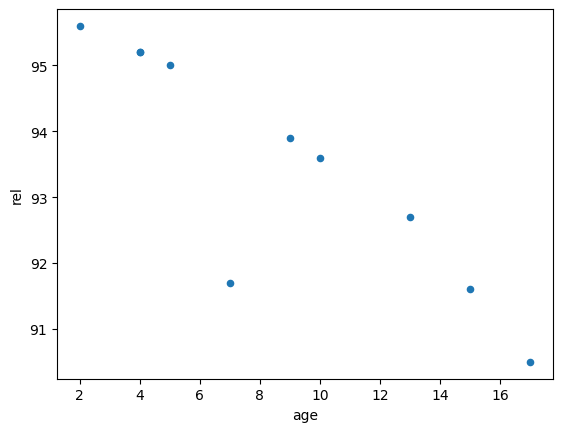

In [99]:
tables['dispatch'].plot.scatter(x='age', y='rel')

In [91]:
inv['lifetime_cost'] / (profits[annual] * inv['life_exp'])

Type
naturalgasCCGT    13.156290
wind               0.719966
naturalgasOCGT    -0.454577
solar              0.252496
powderCoal         1.637313
nuclear            1.440687
biomass            1.925935
dtype: float64

In [67]:
inv['fuel'] = fuel_costs

In [81]:
inv

,Plant name,Type,rel,eff,construct,permit,life_exp,down,loan,num_loan,maint,cap_range,cap_range,Buy,fuel,lifetime_cost
0,,naturalgasCCGT,96.0,59.9,3,1,30,0.146,0.056,15,0.062,500.00-900.00,,,25.706536,2.846
1,,wind,96.0,NaN,1,1,25,0.443,0.171,15,0.047,100.00-700.00,,,0.000000,4.183
2,,naturalgasOCGT,96.0,39.9,2,0,30,0.111,0.058,10,0.025,100.00-500.00,,,38.592017,1.441
3,,solar,96.0,0.0,1,1,25,0.142,0.055,15,0.020,100.00-700.00,,,0.000000,1.467
4,,powderCoal,96.0,41.8,4,1,40,0.269,0.086,20,0.120,400.00-1000.00,,,14.696268,6.789
5,,nuclear,96.0,34.1,5,2,50,1.200,0.385,20,0.110,900.00-1300.00,,,3.709514,14.400
6,,biomass,96.0,41.8,4,1,40,0.288,0.092,20,0.129,400.00-1000.00,,,15.730205,7.288


In [ ]:
elec_price = 
exp_earning = 

In [22]:
total_cost

0     2.846
1     4.183
2     1.441
3     1.467
4     6.789
5    14.400
6     7.288
dtype: float64